НИРС — Анализ чувствительности результатов событийного анализа

**Тема:** Анализ чувствительности результатов событийного анализа к выбору параметров исследования  
**Период:** 2015–2019  
**Выборка:** 11 компаний, 110 дивидендных событий  
**Параметры:** 3 модели × 3 окна события × 3 оценочных окна = 27 комбинаций

## 1. Загрузка данных

In [9]:
import os
import sys

sys.path.insert(0, os.path.join(os.path.dirname(''), '..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from core.nirs import (
    load_events, load_rf, load_prices,
    EventStudyRunner,
)

# --- Пути ---
STOCKS_DIR = '../data/stocks'
EVENTS_PATH = '../data/stocks/dividends_all.csv'
RF_PATH = '../data/stocks/RUONIA_RC_F11_01_2010_T13_03_2026.xlsx'

TICKERS = ['CHMF', 'FEES', 'GMKN', 'LKOH', 'MGNT',
           'MOEX', 'MTSS', 'RTKM', 'SBER', 'TATN', 'UPRO']

START = '2013-01-01'  # с запасом для max оценочного окна 300 дней
END = '2019-12-31'

In [10]:
from datetime import date

events = load_events(EVENTS_PATH)
prices = load_prices(STOCKS_DIR, tickers=TICKERS, start_date=START, end_date=END)
market = prices.pop('IMOEX', None)

# Если IMOEX не нашёлся под таким ключом — загружаем отдельно
if market is None:
    imoex_prices = load_prices(STOCKS_DIR, tickers=['IMOEX'], start_date=START, end_date=END)
    market = imoex_prices.get('IMOEX')

rf = load_rf(RF_PATH, start=date(2013, 1, 1), end=date(2019, 12, 31))

print(f'Событий загружено:  {len(events)}')
print(f'Тикеров загружено:  {len(prices)}')
print(f'IMOEX строк:        {len(market) if market is not None else "НЕТ"}')
print(f'RUONIA строк:       {len(rf)}')
print()
print('Котировки по тикерам:')
for t, s in sorted(prices.items()):
    print(f'  {t}: {len(s)} торговых дней  ({s.index.min().date()} – {s.index.max().date()})')

C:\Users\Ruslan\anaconda3\envs\data-core\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


Событий загружено:  110
Тикеров загружено:  11
IMOEX строк:        1758
RUONIA строк:       1722

Котировки по тикерам:
  CHMF: 1759 торговых дней  (2013-01-09 – 2019-12-30)
  FEES: 1759 торговых дней  (2013-01-09 – 2019-12-30)
  GMKN: 1759 торговых дней  (2013-01-09 – 2019-12-30)
  LKOH: 1759 торговых дней  (2013-01-09 – 2019-12-30)
  MGNT: 1759 торговых дней  (2013-01-09 – 2019-12-30)
  MOEX: 1731 торговых дней  (2013-02-18 – 2019-12-30)
  MTSS: 1750 торговых дней  (2013-01-09 – 2019-12-30)
  RTKM: 1750 торговых дней  (2013-01-09 – 2019-12-30)
  SBER: 1759 торговых дней  (2013-01-09 – 2019-12-30)
  TATN: 1759 торговых дней  (2013-01-09 – 2019-12-30)
  UPRO: 1759 торговых дней  (2013-01-09 – 2019-12-30)


## 2. Промежуточный результат — одна компания, одна конфигурация

In [11]:
from core.nirs import EventStudyConfig

runner = EventStudyRunner(prices=prices, market=market, rf=rf)

# Тестовая конфигурация
cfg_test = EventStudyConfig(
    model='market_model',
    event_window=(-10, 10),
    estimation_window=200,
)

# Фильтруем события только по LKOH
lkoh_events = [e for e in events if e.ticker == 'LKOH']

company_results = runner.analyze_all_events(lkoh_events, cfg_test)
for cr in company_results:
    print(f'{cr.ticker}: mean_CAR={cr.mean_car:.4f}  t={cr.t_stat:.3f}  '
          f'p={cr.p_value:.3f}  significant={cr.significant}  n={cr.n_events}')

LKOH: mean_CAR=-0.0042  t=-0.265  p=0.797  significant=False  n=10


## 3. Полное исследование — 27 комбинаций

### Описание колонок результирующей таблицы

Каждая строка соответствует одной из 27 комбинаций параметров (3 модели × 3 событийных окна × 3 оценочных окна).
Агрегирование происходит **по компаниям**: сначала считается mean_CAR по каждой из 11 компаний, затем t-тест проверяет, отличается ли среднее этих 11 значений от нуля.

| Колонка | Описание |
|---|---|
| `model` | Модель нормальной доходности: `mean_adjusted` — постоянная средняя; `market_model` — рыночная модель (OLS: r = α + β·r_m); `capm` — CAPM (r = rf + β·(r_m − rf)) |
| `event_window` | Событийное окно: диапазон дней относительно даты события (t = 0), например [-3, +3] |
| `estimation_window` | Длина оценочного окна (торговые дни), предшествующего событийному: 100, 200 или 300 дней |
| `mean_car` | Средняя накопленная аномальная доходность (CAR) по 11 компаниям (equal-weighted) |
| `std_car` | Стандартное отклонение mean_CAR между компаниями |
| `t_stat` | t-статистика одновыборочного t-теста (H₀: mean_CAR = 0) |
| `p_value` | p-значение двустороннего t-теста |
| `significant` | Статистическая значимость при уровне α = 5% (p < 0.05) |

In [22]:
COMPANY_NAMES = {
    'CHMF': 'Северсталь',
    'FEES': 'ФСК ЕЭС',
    'GMKN': 'ГМК Норильский никель',
    'LKOH': 'Лукойл',
    'MGNT': 'Магнит',
    'MOEX': 'Московская биржа',
    'MTSS': 'МТС',
    'RTKM': 'Ростелеком',
    'SBER': 'Сбербанк',
    'TATN': 'Татнефть',
    'UPRO': 'Юнипро',
}

events_by_ticker = {}
for ev in events:
    events_by_ticker.setdefault(ev.ticker, []).append(ev)

# --- Промежуточный уровень: по компаниям (297 строк) ---
company_rows = []
for config in runner.ALL_CONFIGS:
    for cr in runner.analyze_all_events(events, config):
        dates = sorted(e.event_date for e in events_by_ticker.get(cr.ticker, []))
        company_rows.append({
            'model': config.model,
            'event_window': f"[{config.event_window[0]}, +{config.event_window[1]}]",
            'estimation_window': config.estimation_window,
            'ticker': cr.ticker,
            'company': COMPANY_NAMES.get(cr.ticker, cr.ticker),
            'first_event': dates[0] if dates else None,
            'last_event': dates[-1] if dates else None,
            'n_events': cr.n_events,
            'mean_car': cr.mean_car,
            'std_car': cr.std_car,
            't_stat': cr.t_stat,
            'p_value': cr.p_value,
            'significant': cr.significant,
        })

company_df = pd.DataFrame(company_rows)
groups_by_config = company_df.groupby(['model', 'event_window', 'estimation_window'])
print(len(groups_by_config))
for (model, ew, esw), group in groups_by_config:
    print(f'\n{model} | окно {ew} | оценочное {esw} дней. Значимо={group["significant"].sum()}')
    display(group[['ticker', 'company', 'n_events', 'mean_car', 't_stat', 'p_value', 'significant']].reset_index(drop=True))

27

capm | окно [-10, +10] | оценочное 100 дней. Значимо=0


,ticker,company,n_events,mean_car,t_stat,p_value,significant
0,LKOH,Лукойл,10,0.000935,0.0672,0.9479,False
1,TATN,Татнефть,10,0.002251,0.0937,0.9274,False
2,SBER,Сбербанк,5,0.025294,0.5577,0.6068,False
3,MOEX,Московская биржа,6,-0.016401,-0.4767,0.6537,False
4,GMKN,ГМК Норильский никель,12,0.001084,0.0515,0.9599,False
5,CHMF,Северсталь,20,0.022162,1.5253,0.1436,False
6,MTSS,МТС,11,-0.001008,-0.1098,0.9148,False
7,RTKM,Ростелеком,6,0.011809,1.1846,0.2894,False
8,FEES,ФСК ЕЭС,7,0.035478,1.4090,0.2085,False
9,UPRO,Юнипро,11,0.000865,0.0749,0.9417,False



capm | окно [-10, +10] | оценочное 200 дней. Значимо=0


,ticker,company,n_events,mean_car,t_stat,p_value,significant
0,LKOH,Лукойл,10,0.001286,0.0923,0.9285,False
1,TATN,Татнефть,10,-0.000333,-0.0141,0.9890,False
2,SBER,Сбербанк,5,0.025582,0.5649,0.6023,False
3,MOEX,Московская биржа,6,-0.013552,-0.4255,0.6881,False
4,GMKN,ГМК Норильский никель,12,-0.000968,-0.0485,0.9622,False
5,CHMF,Северсталь,20,0.021817,1.5095,0.1476,False
6,MTSS,МТС,11,-0.001415,-0.1569,0.8784,False
7,RTKM,Ростелеком,6,0.011848,1.1369,0.3071,False
8,FEES,ФСК ЕЭС,7,0.026870,0.9594,0.3744,False
9,UPRO,Юнипро,11,-0.001281,-0.1208,0.9063,False



capm | окно [-10, +10] | оценочное 300 дней. Значимо=0


...

,ticker,company,n_events,mean_car,t_stat,p_value,significant
0,LKOH,Лукойл,10,0.009776,0.8276,0.4293,False
1,TATN,Татнефть,10,0.003363,0.1760,0.8642,False
2,SBER,Сбербанк,5,0.034098,1.1786,0.3039,False
3,MOEX,Московская биржа,6,-0.019361,-0.7460,0.4892,False
4,GMKN,ГМК Норильский никель,12,0.002872,0.1589,0.8767,False
5,CHMF,Северсталь,20,0.011994,1.3804,0.1835,False
6,MTSS,МТС,11,0.004667,0.3105,0.7625,False
7,RTKM,Ростелеком,6,0.005044,0.3721,0.7250,False
8,FEES,ФСК ЕЭС,7,-0.021258,-0.8065,0.4507,False
9,UPRO,Юнипро,11,-0.000429,-0.0552,0.9571,False



mean_adjusted | окно [-3, +3] | оценочное 200 дней. Значимо=0


,ticker,company,n_events,mean_car,t_stat,p_value,significant
0,LKOH,Лукойл,10,0.009769,0.8580,0.4131,False
1,TATN,Татнефть,10,0.003222,0.1700,0.8688,False
2,SBER,Сбербанк,5,0.030858,1.1950,0.2981,False
3,MOEX,Московская биржа,6,-0.015984,-0.6221,0.5612,False
4,GMKN,ГМК Норильский никель,12,0.000322,0.0188,0.9853,False
5,CHMF,Северсталь,20,0.008281,1.0479,0.3078,False
6,MTSS,МТС,11,0.004730,0.3163,0.7583,False
7,RTKM,Ростелеком,6,0.001997,0.1415,0.8930,False
8,FEES,ФСК ЕЭС,7,-0.018972,-0.6157,0.5607,False
9,UPRO,Юнипро,11,0.000216,0.0276,0.9785,False



mean_adjusted | окно [-3, +3] | оценочное 300 дней. Значимо=0


,ticker,company,n_events,mean_car,t_stat,p_value,significant
0,LKOH,Лукойл,10,0.010567,0.9547,0.3647,False
1,TATN,Татнефть,10,0.002962,0.1566,0.8790,False
2,SBER,Сбербанк,5,0.032934,1.3600,0.2454,False
3,MOEX,Московская биржа,6,-0.016459,-0.6635,0.5364,False
4,GMKN,ГМК Норильский никель,12,0.000675,0.0395,0.9692,False
5,CHMF,Северсталь,20,0.009621,1.2309,0.2334,False
6,MTSS,МТС,11,0.005759,0.3989,0.6984,False
7,RTKM,Ростелеком,6,0.004422,0.3175,0.7637,False
8,FEES,ФСК ЕЭС,7,-0.020678,-0.6033,0.5684,False
9,UPRO,Юнипро,11,-0.002333,-0.3070,0.7652,False


In [13]:
# --- Агрегированный уровень: 27 конфигураций ---
results_df = runner.run_sensitivity_study(events)
print('\nАгрегированный уровень (по конфигурациям):')
results_df


Агрегированный уровень (по конфигурациям):


,model,event_window,estimation_window,mean_car,std_car,t_stat,p_value,significant
0,mean_adjusted,"[-3, +3]",100,0.004004,0.015152,0.8765,0.4013,False
1,mean_adjusted,"[-3, +3]",200,0.003478,0.013515,0.8536,0.4133,False
2,mean_adjusted,"[-3, +3]",300,0.003651,0.014385,0.8418,0.4196,False
3,mean_adjusted,"[-10, +10]",100,0.007078,0.021091,1.1130,0.2917,False
4,mean_adjusted,"[-10, +10]",200,0.005422,0.017383,1.0345,0.3253,False
5,mean_adjusted,"[-10, +10]",300,0.005424,0.019222,0.9358,0.3714,False
6,mean_adjusted,"[-20, +20]",100,0.006359,0.018245,1.1559,0.2746,False
7,mean_adjusted,"[-20, +20]",200,0.006684,0.016000,1.3856,0.1960,False
8,mean_adjusted,"[-20, +20]",300,0.005270,0.014909,1.1724,0.2682,False
9,market_model,"[-3, +3]",100,0.005857,0.006158,3.1547,0.0102,True


## 4. Сводная таблица: значимые комбинации

In [14]:
sig = results_df[results_df['significant']]
print(f'Значимых комбинаций (p < 0.05): {len(sig)} из {len(results_df)}')
sig[['model', 'event_window', 'estimation_window', 'mean_car', 't_stat', 'p_value']]

Значимых комбинаций (p < 0.05): 4 из 27


,model,event_window,estimation_window,mean_car,t_stat,p_value
9,market_model,"[-3, +3]",100,0.005857,3.1547,0.0102
10,market_model,"[-3, +3]",200,0.005350,3.2550,0.0086
18,capm,"[-3, +3]",100,0.005899,3.1210,0.0109
19,capm,"[-3, +3]",200,0.005079,2.4292,0.0355


## 5. График средних CAR по окну события (одна конфигурация)

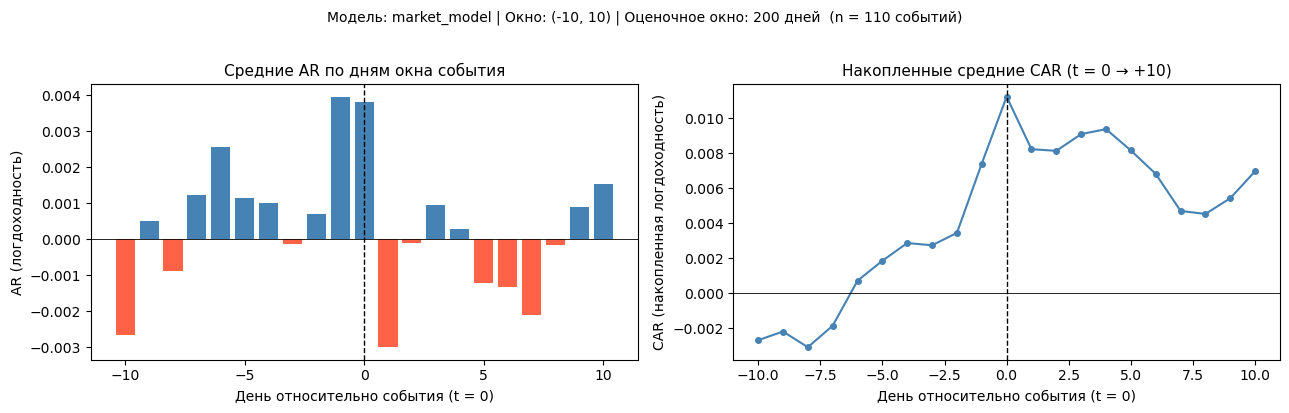

In [15]:
cfg_plot = EventStudyConfig(
    model='market_model',
    event_window=(-10, 10),
    estimation_window=200,
)

# Собираем AR по всем событиям
all_ar: list[list[float]] = []
for ev in events:
    res = runner.analyze_single_event(ev, cfg_plot)
    if res is not None and len(res.ar) == 21:  # ровно 21 день [-10..+10]
        all_ar.append(res.ar)

if all_ar:
    ar_matrix = np.array(all_ar)  # shape (n_events, 21)
    mean_ar = ar_matrix.mean(axis=0)
    cum_ar = np.cumsum(mean_ar)
    days = list(range(-10, 11))

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    axes[0].bar(days, mean_ar, color=['tomato' if x < 0 else 'steelblue' for x in mean_ar])
    axes[0].axvline(0, color='black', lw=1, linestyle='--')
    axes[0].axhline(0, color='black', lw=0.6)
    axes[0].set_title('Средние AR по дням окна события', fontsize=11)
    axes[0].set_xlabel('День относительно события (t = 0)')
    axes[0].set_ylabel('AR (логдоходность)')

    axes[1].plot(days, cum_ar, marker='o', markersize=4, color='steelblue')
    axes[1].axvline(0, color='black', lw=1, linestyle='--')
    axes[1].axhline(0, color='black', lw=0.6)
    axes[1].set_title('Накопленные средние CAR (t = 0 → +10)', fontsize=11)
    axes[1].set_xlabel('День относительно события (t = 0)')
    axes[1].set_ylabel('CAR (накопленная логдоходность)')

    plt.suptitle(f'Модель: {cfg_plot.model} | Окно: {cfg_plot.event_window} | '
                 f'Оценочное окно: {cfg_plot.estimation_window} дней  '
                 f'(n = {len(all_ar)} событий)', fontsize=10, y=1.02)
    plt.tight_layout()
    plt.savefig('../docs/car_plot.png', dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()
else:
    print('Недостаточно данных для построения графика.')

## 6. Сравнение моделей (heatmap t-статистик)

C:\Users\Ruslan\AppData\Local\Temp\ipykernel_7536\3350727977.py:35: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


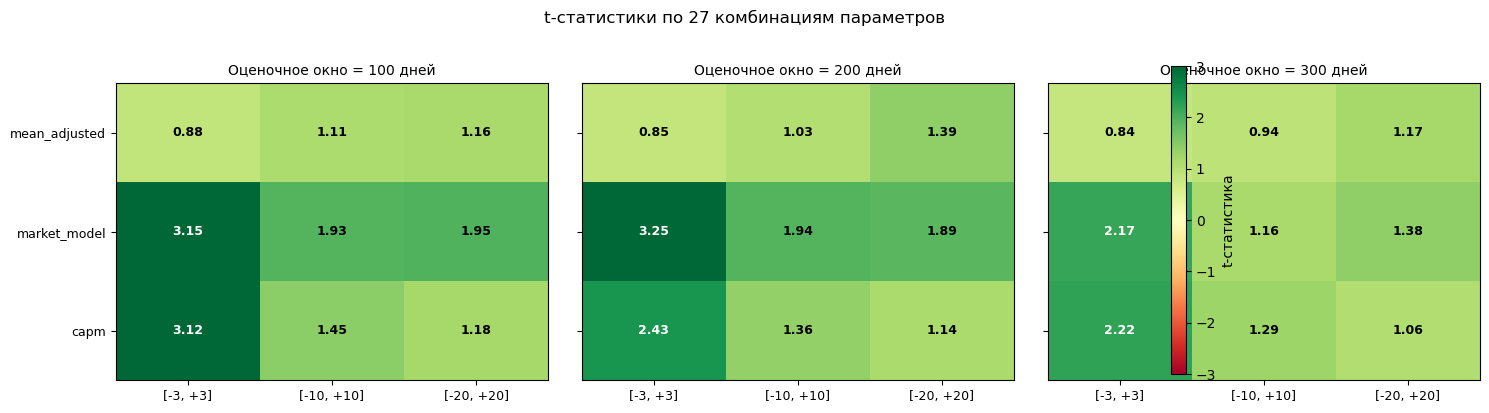

In [16]:
models = ['mean_adjusted', 'market_model', 'capm']
windows = ['[-3, +3]', '[-10, +10]', '[-20, +20]']
est_windows = [100, 200, 300]

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, esw in zip(axes, est_windows):
    sub = results_df[results_df['estimation_window'] == esw]
    matrix = []
    for m in models:
        row = []
        for ew in windows:
            val = sub[(sub['model'] == m) & (sub['event_window'] == ew)]['t_stat']
            row.append(float(val.iloc[0]) if len(val) > 0 else 0.0)
        matrix.append(row)

    mat = np.array(matrix)
    im = ax.imshow(mat, cmap='RdYlGn', vmin=-3, vmax=3, aspect='auto')
    ax.set_xticks(range(3))
    ax.set_xticklabels(windows, fontsize=9)
    ax.set_yticks(range(3))
    ax.set_yticklabels(models, fontsize=9)
    ax.set_title(f'Оценочное окно = {esw} дней', fontsize=10)

    for i in range(3):
        for j in range(3):
            ax.text(j, i, f'{mat[i, j]:.2f}', ha='center', va='center',
                    fontsize=9, fontweight='bold',
                    color='white' if abs(mat[i, j]) > 2 else 'black')

plt.colorbar(im, ax=axes, label='t-статистика')
plt.suptitle('t-статистики по 27 комбинациям параметров', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('../docs/heatmap.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

## 7. Экспорт результатов

In [17]:
out_path = '../reports/sensitivity_results.csv'
results_df.to_csv(out_path, index=False, encoding='utf-8-sig')
print(f'Результаты сохранены: {out_path}')
results_df[['model', 'event_window', 'estimation_window',
            'mean_car', 'std_car', 't_stat', 'p_value', 'significant']]

Результаты сохранены: ../reports/sensitivity_results.csv


,model,event_window,estimation_window,mean_car,std_car,t_stat,p_value,significant
0,mean_adjusted,"[-3, +3]",100,0.004004,0.015152,0.8765,0.4013,False
1,mean_adjusted,"[-3, +3]",200,0.003478,0.013515,0.8536,0.4133,False
2,mean_adjusted,"[-3, +3]",300,0.003651,0.014385,0.8418,0.4196,False
3,mean_adjusted,"[-10, +10]",100,0.007078,0.021091,1.1130,0.2917,False
4,mean_adjusted,"[-10, +10]",200,0.005422,0.017383,1.0345,0.3253,False
5,mean_adjusted,"[-10, +10]",300,0.005424,0.019222,0.9358,0.3714,False
6,mean_adjusted,"[-20, +20]",100,0.006359,0.018245,1.1559,0.2746,False
7,mean_adjusted,"[-20, +20]",200,0.006684,0.016000,1.3856,0.1960,False
8,mean_adjusted,"[-20, +20]",300,0.005270,0.014909,1.1724,0.2682,False
9,market_model,"[-3, +3]",100,0.005857,0.006158,3.1547,0.0102,True
